# 1. Extração e tratamento dos dados

In [56]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

### Leitura dos dados

In [57]:
df = pd.read_csv("episat_dataset.csv")
df

,municipio_codigo,nome_municipio,uf,semana_epidemiologica,temperatura_media_c,temperatura_max_c,umidade_relativa_pct,precipitacao_acumulada_mm,ndvi_medio,cobertura_agua_pct,altitude_media_m,populacao_exposta,densidade_demografica,indice_saneamento_pct,casos_semana_anterior,casos_por_100k,nivel_risco
0,MUN_001,São Paulo,SP,1,19.77,28.93,80.54,2.31,0.241,0.00,787.5,2259084,39.3,74.5,2831,125.33,Baixo
1,MUN_001,São Paulo,SP,2,10.33,19.79,64.69,7.78,0.055,0.00,787.5,2259084,39.3,74.5,574,25.41,Baixo
2,MUN_001,São Paulo,SP,3,12.53,22.18,60.21,5.84,0.328,4.80,787.5,2259084,39.3,74.5,872,38.62,Baixo
3,MUN_001,São Paulo,SP,4,19.85,26.38,76.22,34.21,0.245,0.00,787.5,2259084,39.3,74.5,3526,156.12,Baixo
4,MUN_001,São Paulo,SP,5,24.31,33.76,67.64,12.10,0.301,0.00,787.5,2259084,39.3,74.5,3296,145.92,Baixo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,MUN_140,Açailândia,MA,46,15.06,20.59,64.03,88.67,0.190,11.19,176.5,1120654,333.3,72.4,3045,271.74,Alto
6996,MUN_140,Açailândia,MA,47,20.03,22.83,61.05,3.80,0.170,0.00,176.5,1120654,333.3,72.4,1592,142.13,Baixo
6997,MUN_140,Açailândia,MA,48,19.90,27.54,44.22,12.07,0.165,0.47,176.5,1120654,333.3,72.4,1476,131.76,Baixo
6998,MUN_140,Açailândia,MA,49,28.73,37.03,67.41,22.99,0.218,0.00,176.5,1120654,333.3,72.4,1207,107.73,Baixo


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   municipio_codigo           7000 non-null   str    
 1   nome_municipio             7000 non-null   str    
 2   uf                         7000 non-null   str    
 3   semana_epidemiologica      7000 non-null   int64  
 4   temperatura_media_c        7000 non-null   float64
 5   temperatura_max_c          7000 non-null   float64
 6   umidade_relativa_pct       7000 non-null   float64
 7   precipitacao_acumulada_mm  7000 non-null   float64
 8   ndvi_medio                 7000 non-null   float64
 9   cobertura_agua_pct         7000 non-null   float64
 10  altitude_media_m           7000 non-null   float64
 11  populacao_exposta          7000 non-null   int64  
 12  densidade_demografica      7000 non-null   float64
 13  indice_saneamento_pct      7000 non-null   float64
 14  cas

### Verificação Nulos

In [59]:
df.isnull().sum()

municipio_codigo             0
nome_municipio               0
uf                           0
semana_epidemiologica        0
temperatura_media_c          0
temperatura_max_c            0
umidade_relativa_pct         0
precipitacao_acumulada_mm    0
ndvi_medio                   0
cobertura_agua_pct           0
altitude_media_m             0
populacao_exposta            0
densidade_demografica        0
indice_saneamento_pct        0
casos_semana_anterior        0
casos_por_100k               0
nivel_risco                  0
dtype: int64

### Transformando campos STR

In [60]:
from sklearn.preprocessing import LabelEncoder

# Criando encoder
encoder = LabelEncoder()


df["municipio_codigo"] = encoder.fit_transform(df["municipio_codigo"])
 
df["nome_municipio"] = encoder.fit_transform(df["nome_municipio"])

df["uf"] = encoder.fit_transform(df["uf"])

df["nivel_risco"] = encoder.fit_transform(df["nivel_risco"])



In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   municipio_codigo           7000 non-null   int64  
 1   nome_municipio             7000 non-null   int64  
 2   uf                         7000 non-null   int64  
 3   semana_epidemiologica      7000 non-null   int64  
 4   temperatura_media_c        7000 non-null   float64
 5   temperatura_max_c          7000 non-null   float64
 6   umidade_relativa_pct       7000 non-null   float64
 7   precipitacao_acumulada_mm  7000 non-null   float64
 8   ndvi_medio                 7000 non-null   float64
 9   cobertura_agua_pct         7000 non-null   float64
 10  altitude_media_m           7000 non-null   float64
 11  populacao_exposta          7000 non-null   int64  
 12  densidade_demografica      7000 non-null   float64
 13  indice_saneamento_pct      7000 non-null   float64
 14  cas

### Normalização

In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_normalizar = [
    "temperatura_media_c",
    "temperatura_max_c",
    "umidade_relativa_pct",
    "precipitacao_acumulada_mm",
    "ndvi_medio",
    "cobertura_agua_pct",
    "altitude_media_m",
    "densidade_demografica",
    "indice_saneamento_pct",
    "populacao_exposta",
    "casos_semana_anterior",
]

df[cols_normalizar] = scaler.fit_transform(df[cols_normalizar])

# 2. Modelo de classificação (Nivel_risco)

### Encontrar as melhores colunas

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

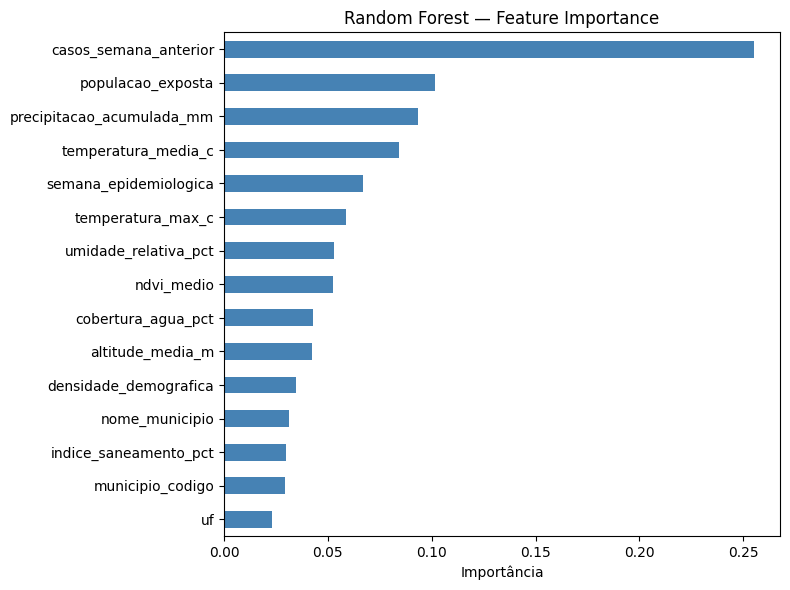

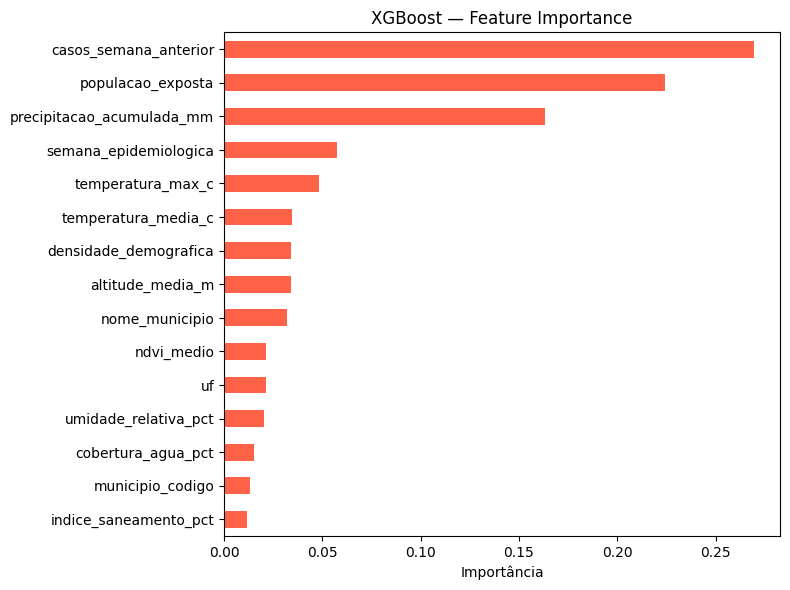

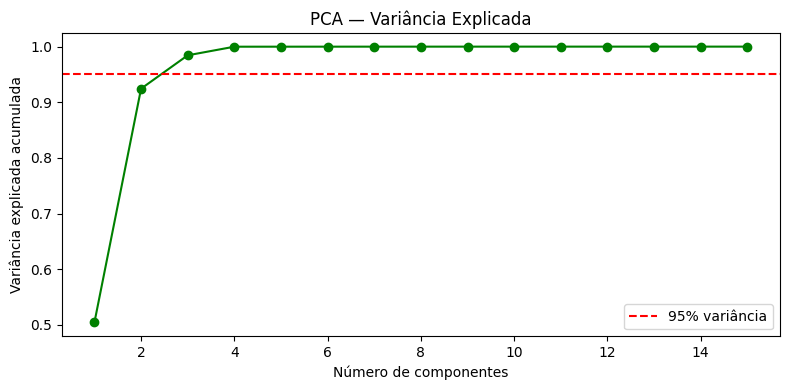

In [64]:
# Definir X e y
# Remover targets e identificadores que não entram no modelo
X = df.drop(columns=["nivel_risco", "casos_por_100k"])
y = df["nivel_risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importancia_rf = pd.Series(rf.feature_importances_, index=X.columns)
importancia_rf = importancia_rf.sort_values(ascending=True)

importancia_rf.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

importancia_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
importancia_xgb = importancia_xgb.sort_values(ascending=True)

importancia_xgb.plot(kind="barh", figsize=(8, 6), color="tomato")
plt.title("XGBoost — Feature Importance")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

pca = PCA(random_state=42)
pca.fit(X_train)

# Variância explicada acumulada
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o", color="green")
plt.axhline(0.95, color="red", linestyle="--", label="95% variância")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA — Variância Explicada")
plt.legend()
plt.tight_layout()
plt.show()

### Modelo de classificação

In [65]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features_selecionadas = [
    "casos_semana_anterior",
    "temperatura_media_c",
    "precipitacao_acumulada_mm",
    "semana_epidemiologica",
    "ndvi_medio",
    "temperatura_max_c",
    "populacao_exposta",
    "cobertura_agua_pct",
    "umidade_relativa_pct",
]

X = df[features_selecionadas]
y = df["nivel_risco"]

X_train, X_test, y_train, y_test = train_test_split(
          #Qtd de teste  #dividir igual   #Selecionar a mesma proporção
    X, y, test_size=0.3, random_state=42, stratify=y
)



In [66]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=["Alto","Baixo","Medio"]))

XGBoost
              precision    recall  f1-score   support

        Alto       0.97      0.96      0.96       525
       Baixo       0.98      0.99      0.98       945
       Medio       0.94      0.95      0.95       630

    accuracy                           0.97      2100
   macro avg       0.97      0.96      0.97      2100
weighted avg       0.97      0.97      0.97      2100



In [67]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Alto","Baixo","Medio"]))

Random Forest
              precision    recall  f1-score   support

        Alto       0.89      0.83      0.86       525
       Baixo       0.91      0.94      0.93       945
       Medio       0.80      0.80      0.80       630

    accuracy                           0.87      2100
   macro avg       0.87      0.86      0.86      2100
weighted avg       0.87      0.87      0.87      2100



In [68]:
# LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("  LightGBM")
print(classification_report(y_test, y_pred_lgbm, target_names=["Alto","Baixo","Medio"]))

  LightGBM
              precision    recall  f1-score   support

        Alto       0.97      0.96      0.97       525
       Baixo       0.98      0.99      0.99       945
       Medio       0.96      0.96      0.96       630

    accuracy                           0.97      2100
   macro avg       0.97      0.97      0.97      2100
weighted avg       0.97      0.97      0.97      2100



In [69]:
# Guardar resultados para o comparativo depois
resultados = {
    "Random Forest": {"y_pred": y_pred_rf,   "accuracy": accuracy_score(y_test, y_pred_rf),   "f1_macro": f1_score(y_test, y_pred_rf,   average="macro")},
    "XGBoost":       {"y_pred": y_pred_xgb,  "accuracy": accuracy_score(y_test, y_pred_xgb),  "f1_macro": f1_score(y_test, y_pred_xgb,  average="macro")},
    "LightGBM":      {"y_pred": y_pred_lgbm, "accuracy": accuracy_score(y_test, y_pred_lgbm), "f1_macro": f1_score(y_test, y_pred_lgbm, average="macro")},
}

               Acurácia  F1-macro
Random Forest    0.8724    0.8619
XGBoost          0.9681    0.9652
LightGBM         0.9733    0.9707


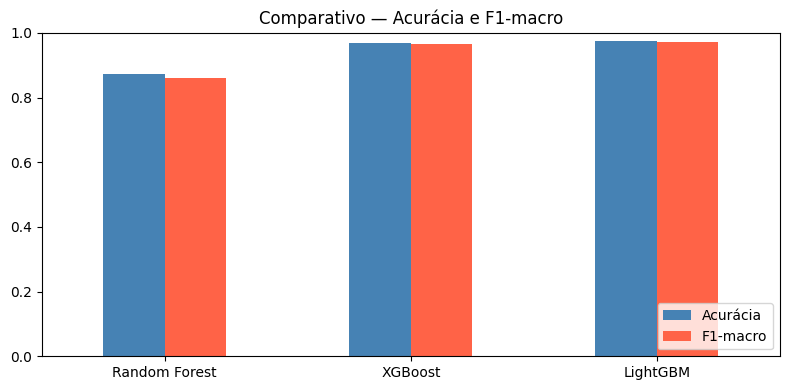

In [70]:
comp = pd.DataFrame({
    nome: {
        "Acurácia": res["accuracy"],
        "F1-macro": res["f1_macro"],
    }
    for nome, res in resultados.items()
}).T.round(4)

print(comp)

comp.plot(kind="bar", figsize=(8, 4), ylim=(0, 1), color=["steelblue","tomato"])
plt.title("Comparativo — Acurácia e F1-macro")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

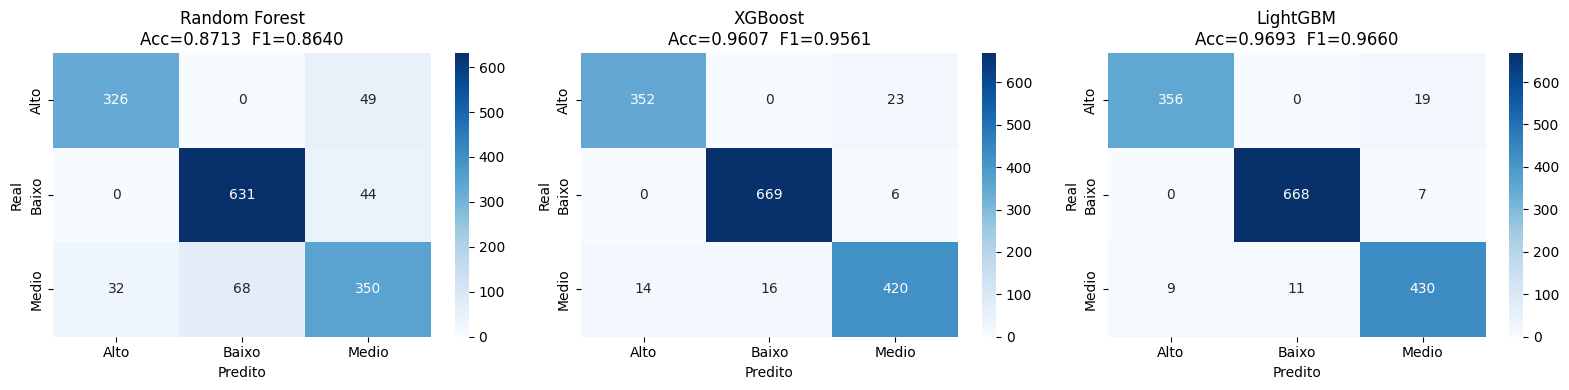

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
classes = ["Alto", "Baixo", "Medio"]

for ax, (nome, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{nome}\nAcc={res['accuracy']:.4f}  F1={res['f1_macro']:.4f}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()